In [161]:
!pip3 install pandas
!pip3 install seaborn
!pip3 install scikit-learn
!pip3 install matplotlib

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [162]:
database = pd.read_csv('1database.csv')

X = database[['X', 'Y']].values
y = database['Class'].values

new_point = np.array([[68,46]])

In [163]:
knn_euclidean = KNeighborsClassifier(n_neighbors=3, p=2)
knn_euclidean.fit(X, y)

distances_euclidean, indices_euclidean = knn_euclidean.kneighbors(new_point)
nearest_distance_euclidean = distances_euclidean[0][0]
nearest_neighbors_euclidean = indices_euclidean[0]

predicted_class_euclidean = knn_euclidean.predict(new_point)[0]

knn_manhattan = KNeighborsClassifier(n_neighbors=3, p=1)
knn_manhattan.fit(X, y)

distances_manhattan, indices_manhattan = knn_manhattan.kneighbors(new_point)
nearest_distance_manhattan = distances_manhattan[0][0]
nearest_neighbors_manhattan = indices_manhattan[0]

predicted_class_manhattan = knn_manhattan.predict(new_point)[0]


In [164]:
print(nearest_distance_euclidean)
print(', '.join(map(str, nearest_neighbors_euclidean)))
print(predicted_class_euclidean)

print(nearest_distance_manhattan)
print(', '.join(map(str, nearest_neighbors_manhattan)))
print(predicted_class_manhattan)


12.083045973594572
6, 9, 1
1
16.0
6, 9, 1
1


In [165]:
database = pd.read_csv('2database.csv')
database = database.drop(columns=['education', 'marital-status'])

numeric_features = database.select_dtypes(include=['int64', 'float64']).columns
categorical_features = database.select_dtypes(include=['object']).columns

num_categorical_features = len(categorical_features)
print(num_categorical_features)

6


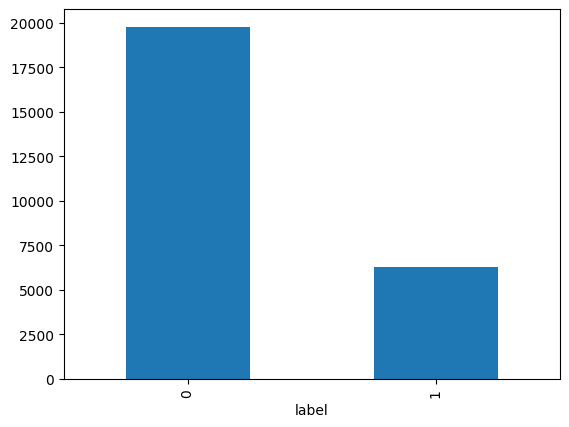

Доля объектов класса 0: 0.759


In [166]:
database['label'].value_counts().plot(kind='bar')
plt.show()

class_0_share = database['label'].value_counts(normalize=True)[0]
print(f"Доля объектов класса 0: {class_0_share:.3f}")

In [167]:
numeric_data = database.select_dtypes(include=['int64', 'float64'])
X = numeric_data.drop(columns=['label'])
y = numeric_data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

In [168]:
mean_fnlwgt = X_train['fnlwgt'].mean()
print(mean_fnlwgt)

190069.76254918898


In [169]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1-score без масштабирования: {f1:.3f}")

F1-score без масштабирования: 0.371


In [170]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mean_fnlwgt_scaled = X_train_scaled[:, X.columns.get_loc('fnlwgt')].mean()
print(f"Среднее значение fnlwgt после масштабирования: {mean_fnlwgt_scaled:.3f}")

knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)

f1_scaled = f1_score(y_test, y_pred_scaled)
print(f"F1-score после масштабирования: {f1_scaled:.3f}")

Среднее значение fnlwgt после масштабирования: 0.121
F1-score после масштабирования: 0.504


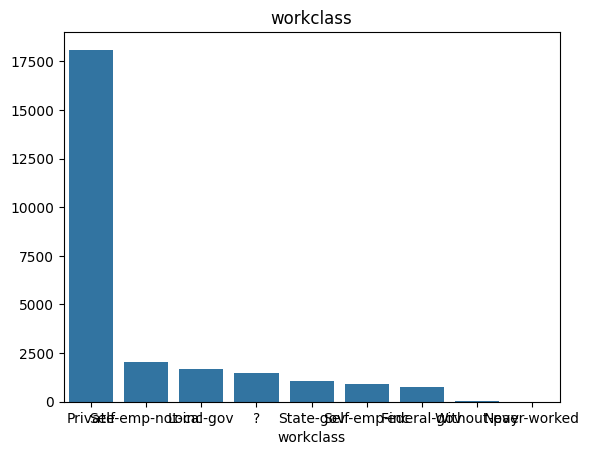

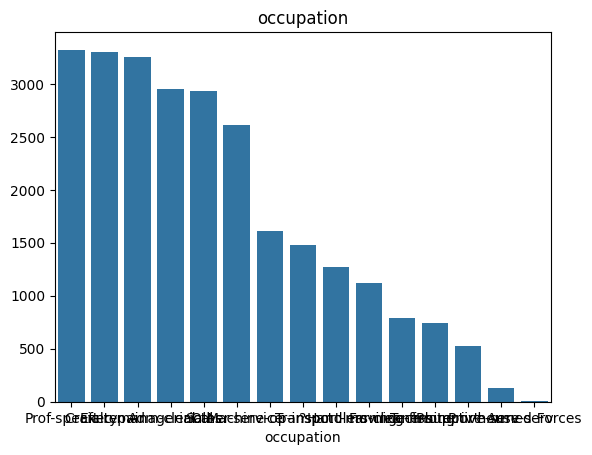

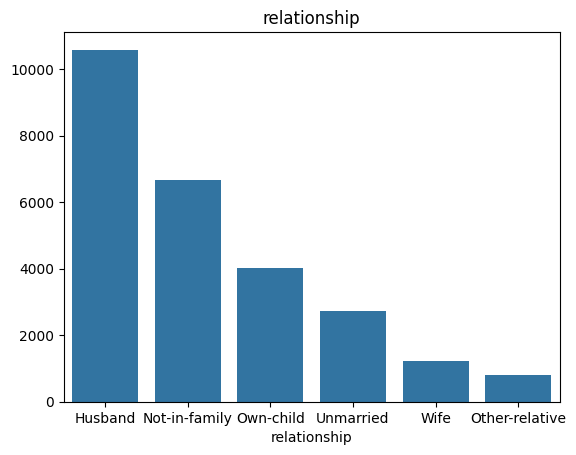

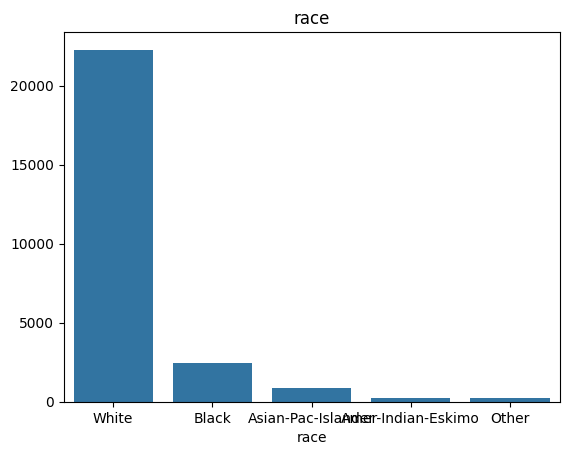

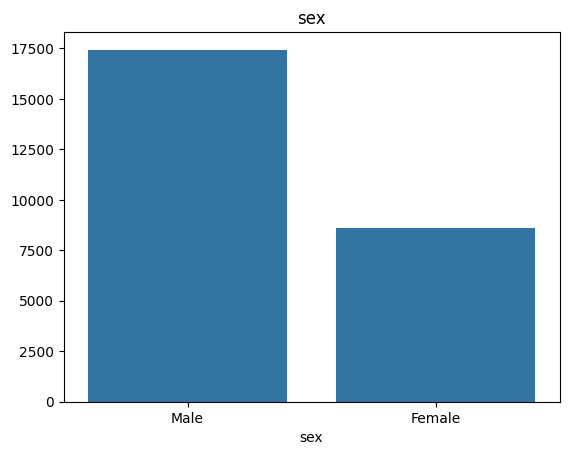

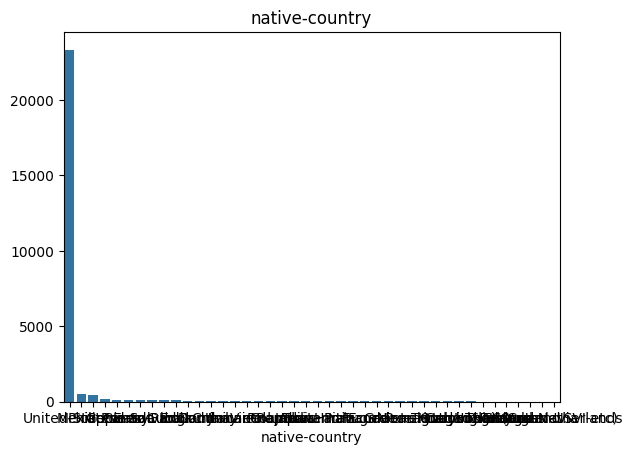

In [171]:
database = pd.read_csv('2database.csv')
database = database.drop(columns=['education', 'marital-status'])

for col in database.select_dtypes(include=['object']).columns:
    sns.barplot(x=database[col].value_counts().index, y=database[col].value_counts().values)
    plt.title(col)
    plt.show()

In [172]:
missing_values_count = database.isnull().sum().sum()
print(missing_values_count)

data_dropped = database.dropna()

data_encoded = pd.get_dummies(data_dropped, drop_first=True)

print(data_encoded.shape[1])

X = data_encoded.drop(columns=['label'])
y = data_encoded['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

f1_encoded = f1_score(y_test, y_pred)
print(f1_encoded)


0
80
0.6080617495711835


In [173]:
data_filled = database.fillna(database.mode().iloc[0])

data_encoded_filled = pd.get_dummies(data_filled, drop_first=True)

X = data_encoded_filled.drop(columns=['label'])
y = data_encoded_filled['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

f1_filled = f1_score(y_test, y_pred)
print(f1_filled)

0.6080617495711835
